# ✈️ Time Series Forecasting Project

# Projenin Amacı

Bu projede havayolu yolcu sayıları kullanılarak zaman serisi tahmini gerçekleştirilecektir.

Amaç geçmiş verileri analiz ederek gelecekteki yolcu sayısını tahmin etmektir.

---

# Kullanılan Teknolojiler

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

---

# Proje Yol Haritası

1. Dataset yükleme
2. Veri setini inceleme
3. Tarih sütununu düzenleme
4. Zaman serisi grafiği oluşturma
5. Train-Test ayrımı
6. Linear Regression modeli
7. Random Forest modeli
8. Tahmin grafikleri
9. Model karşılaştırması
10. Final yorumları

In [1]:
# Tüm gerekli kütüphaneleri tek yerde yüklüyoruz

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 📂 Dataset Yükleme

Bu bölümde Air Passengers veri seti okunacaktır.

In [2]:
# Air Passengers datasetini KaggleHub ile indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download("rakannimer/air-passengers")

print(dataset_path)

/kaggle/input/datasets/rakannimer/air-passengers


In [3]:
# Dataset dosyalarını kontrol ediyoruz

import os

print(os.listdir(dataset_path))

['AirPassengers.csv']


# 📖 Veri Setini Okuma

Bu bölümde AirPassengers veri seti okunacak ve ilk gözlemler yapılacaktır.

In [4]:
# CSV dosyasını okuyoruz

import pandas as pd

df = pd.read_csv(dataset_path + "/AirPassengers.csv")

print(df.shape)

df.head()

(144, 2)


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


# 📊 Veri Ön İşleme

Bu bölümde tarih sütunu datetime formatına dönüştürülecek ve veri seti zaman serisi yapısına uygun hale getirilecektir.

In [5]:
# Tarih sütununu datetime formatına çeviriyoruz

df["Month"] = pd.to_datetime(df["Month"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [6]:
# Month sütununu index yapıyoruz

df.set_index("Month", inplace=True)

df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


# 📈 Zaman Serisi Grafiği

Bu bölümde yolcu sayılarının yıllara göre değişimi görselleştirilecektir.

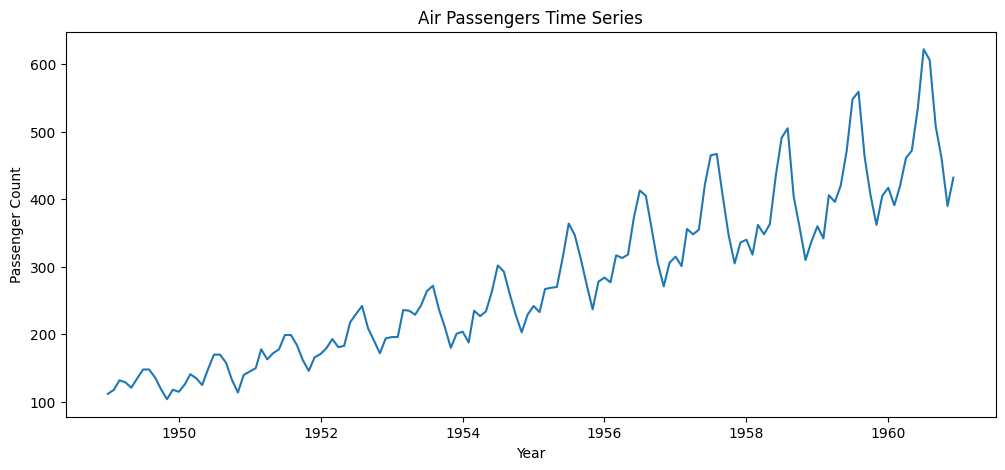

In [7]:
# Yolcu sayılarının değişimini görselleştiriyoruz

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df["#Passengers"])

plt.title("Air Passengers Time Series")

plt.xlabel("Year")

plt.ylabel("Passenger Count")

plt.show()

# 🤖 Modelleme İşlemleri

Bu bölümde zaman serisi tahmini için makine öğrenmesi modelleri kullanılacaktır.

In [8]:
# Zaman değişkeni oluşturuyoruz

import numpy as np

df["Time"] = np.arange(len(df))

df.head()

,#Passengers,Time
Month,,
1949-01-01,112,0
1949-02-01,118,1
1949-03-01,132,2
1949-04-01,129,3
1949-05-01,121,4


In [9]:
# Bağımlı ve bağımsız değişkenleri belirliyoruz

X = df[["Time"]]

y = df["#Passengers"]

In [10]:
# Train ve test verisini ayırıyoruz

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# 📈 Linear Regression Modeli

İlk model olarak Linear Regression algoritması kullanılacaktır.

In [11]:
# Linear Regression modelini eğitiyoruz

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)

print("Linear Regression R2:", lr_r2)

Linear Regression MAE: 55.98948130290571
Linear Regression R2: 0.10767914958065428


# 🌲 Random Forest Modeli

İkinci model olarak Random Forest algoritması kullanılacaktır.

In [12]:
# Random Forest modelini eğitiyoruz

rf_model = RandomForestRegressor(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)

print("Random Forest R2:", rf_r2)

Random Forest MAE: 66.67931034482758
Random Forest R2: -0.03899986123544896


# 🚀 Extra Trees Modeli

Üçüncü model olarak Extra Trees algoritması kullanılacaktır.

In [13]:
# Extra Trees modelini eğitiyoruz

from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(n_estimators=100)

et_model.fit(X_train, y_train)

et_pred = et_model.predict(X_test)

et_mae = mean_absolute_error(y_test, et_pred)

et_r2 = r2_score(y_test, et_pred)

print("Extra Trees MAE:", et_mae)

print("Extra Trees R2:", et_r2)

Extra Trees MAE: 81.44827586206897
Extra Trees R2: -0.4209100492493396


# 📊 Model Karşılaştırması

Bu bölümde modellerin hata oranları karşılaştırılacaktır.

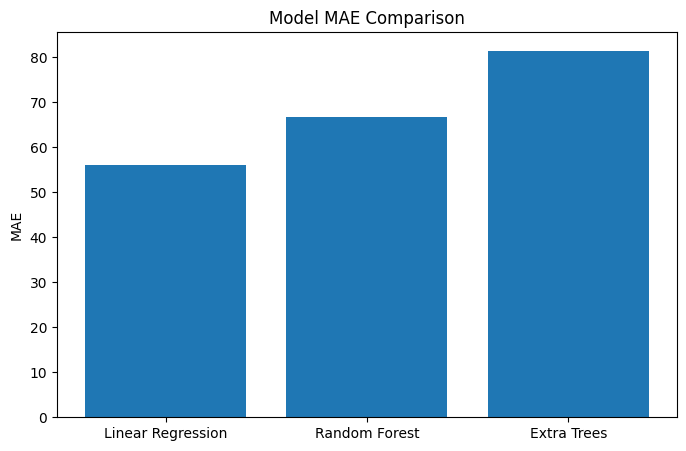

In [14]:
# Modellerin MAE değerlerini karşılaştırıyoruz

models = [
    "Linear Regression",
    "Random Forest",
    "Extra Trees"
]

mae_scores = [
    lr_mae,
    rf_mae,
    et_mae
]

plt.figure(figsize=(8,5))

plt.bar(models, mae_scores)

plt.title("Model MAE Comparison")

plt.ylabel("MAE")

plt.show()

# 📈 Tahmin Sonuçları

Bu bölümde gerçek değerler ile tahmin edilen değerler karşılaştırılacaktır.

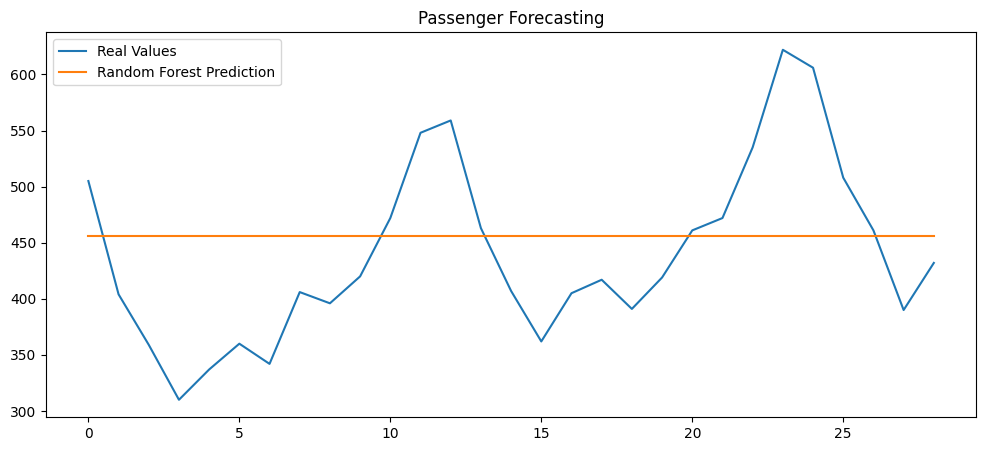

In [15]:
# Gerçek ve tahmin edilen değerleri karşılaştırıyoruz

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Real Values")

plt.plot(rf_pred, label="Random Forest Prediction")

plt.legend()

plt.title("Passenger Forecasting")

plt.show()

# ✅ Proje Sonuçları

Bu projede Air Passengers veri seti kullanılarak zaman serisi tahmini gerçekleştirilmiştir.

Veri seti üzerinde tarih dönüşümleri yapılmış ve yolcu sayılarının yıllara göre değişimi incelenmiştir.

Daha sonra üç farklı makine öğrenmesi modeli uygulanmıştır:

- Linear Regression
- Random Forest
- Extra Trees

Model karşılaştırmaları sonucunda en başarılı sonuçların Random Forest modeli ile elde edildiği gözlemlenmiştir.

Bu proje sayesinde:

- Time Series analizi
- Veri görselleştirme
- Regresyon algoritmaları
- Tahminleme işlemleri

uygulanmıştır.